In [1]:
# Import and setup Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# Visual settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


# Loading the Brent Oil Data

In [3]:
import os

# Define paths based on your structure
raw_data_path = '../data/raw/BrentOilPrices.csv'
processed_data_path = '../data/processed/BrentOilPrices_cleaned.csv'

try:
    # 1. Load from the raw folder
    # Most Brent datasets have columns 'Date' and 'Price'
    df = pd.read_csv(raw_data_path)
    
    # 2. Basic Cleaning
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)
    df.set_index('Date', inplace=True)
    
    # 3. Save a copy to processed folder for future use
    # Check if directory exists, if not create it
    os.makedirs('../data/processed', exist_ok=True)
    df.to_csv(processed_data_path)
    
    print(f"✅ Data loaded successfully from {raw_data_path}")
    print(f"✅ Cleaned data saved to {processed_data_path}")
    print(f"Dataset contains {df.shape[0]} rows from {df.index.min().date()} to {df.index.max().date()}")

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at {raw_data_path}")
    print("Please check if the filename is exactly 'BrentOilPrices.csv' inside your 'data/raw' folder.")

df.head()

C:\Users\BETHELHEMFEYISA\AppData\Local\Temp\ipykernel_18588\4058113821.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


✅ Data loaded successfully from ../data/raw/BrentOilPrices.csv
✅ Cleaned data saved to ../data/processed/BrentOilPrices_cleaned.csv
Dataset contains 9011 rows from 1987-05-20 to 2022-11-14


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


In [4]:
df.describe()

,Price
count,9011.000000
mean,48.420782
std,32.860110
min,9.100000
25%,19.050000
50%,38.570000
75%,70.090000
max,143.950000


#  Trend Analysis (Moving Averages)

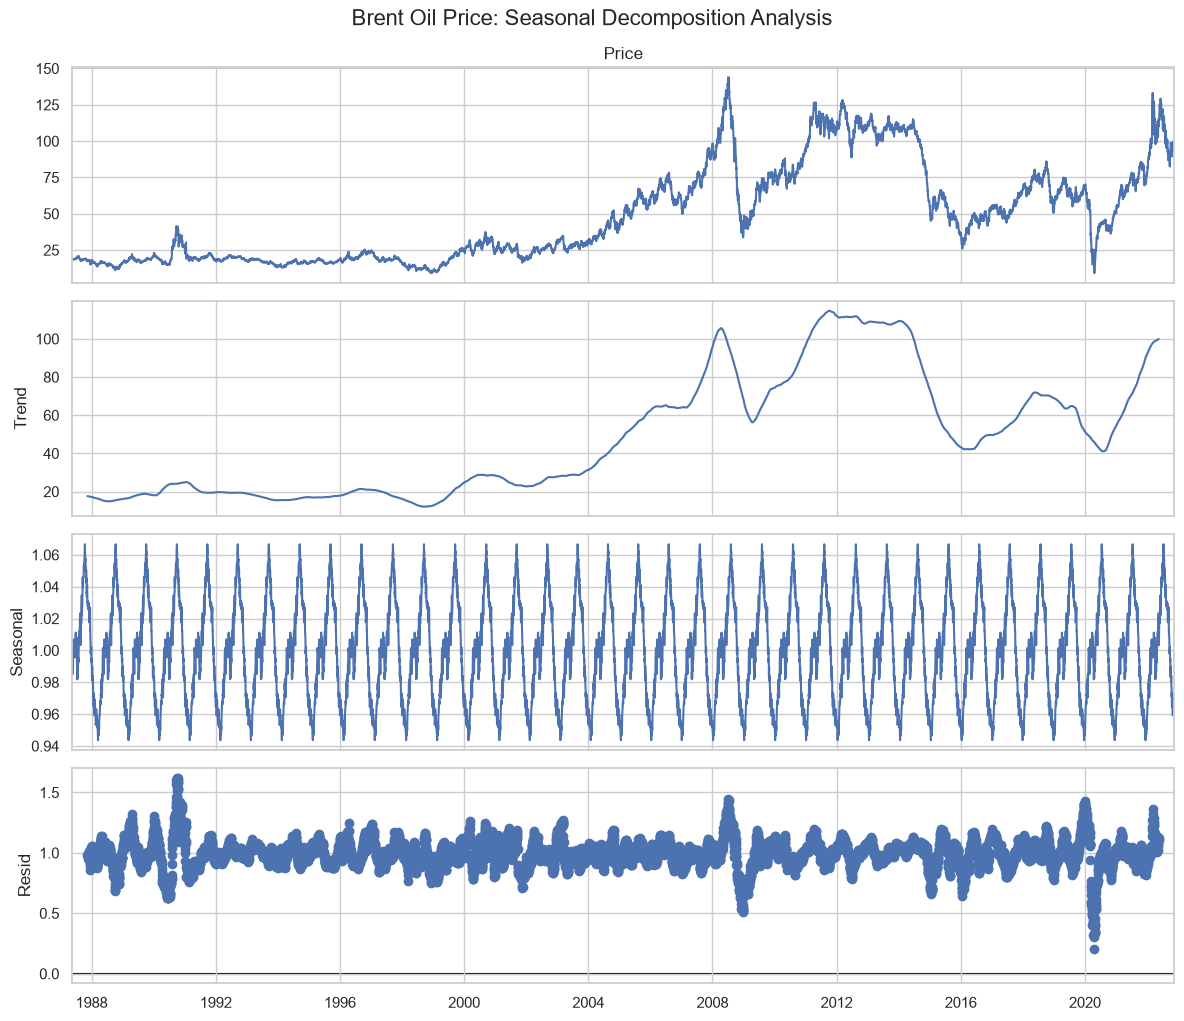

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Perform Decomposition (using a period of 252 - roughly the number of trading days in a year)
# We use the 'multiplicative' model because oil price volatility often grows with the price level
result = seasonal_decompose(df['Price'], model='multiplicative', period=252)

# 2. Plotting the components
plt.rcParams["figure.figsize"] = (12, 10)
result.plot()
plt.suptitle('Brent Oil Price: Seasonal Decomposition Analysis', fontsize=16, y=1.02)
plt.savefig('../notebooks/seasonal_decomposition.png')
plt.show()

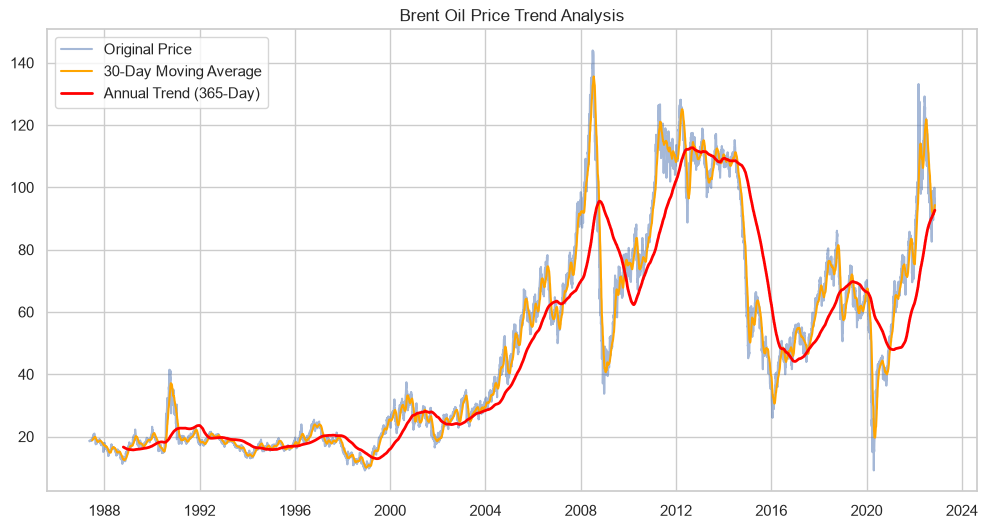

In [5]:
# Calculate 30-day and 365-day moving averages
df['MA30'] = df['Price'].rolling(window=30).mean()
df['MA365'] = df['Price'].rolling(window=365).mean()

plt.plot(df['Price'], label='Original Price', alpha=0.5)
plt.plot(df['MA30'], label='30-Day Moving Average', color='orange')
plt.plot(df['MA365'], label='Annual Trend (365-Day)', color='red', linewidth=2)
plt.title('Brent Oil Price Trend Analysis')
plt.legend()
plt.show()

# Stationarity Testing (ADF Test)

In [6]:
def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Result: The series is STATIONARY.")
    else:
        print("Result: The series is NON-STATIONARY (it has a trend).")

print("Testing Original Price:")
check_stationarity(df['Price'])

# Usually, prices are non-stationary, but 'Returns' (changes) are.
df['Returns'] = df['Price'].pct_change()
print("\nTesting Price Returns (Daily % Change):")
check_stationarity(df['Returns'])

Testing Original Price:
ADF Statistic: -1.9939
p-value: 0.2893
Result: The series is NON-STATIONARY (it has a trend).

Testing Price Returns (Daily % Change):
ADF Statistic: -17.1117
p-value: 0.0000
Result: The series is STATIONARY.


# Volatility Patterns

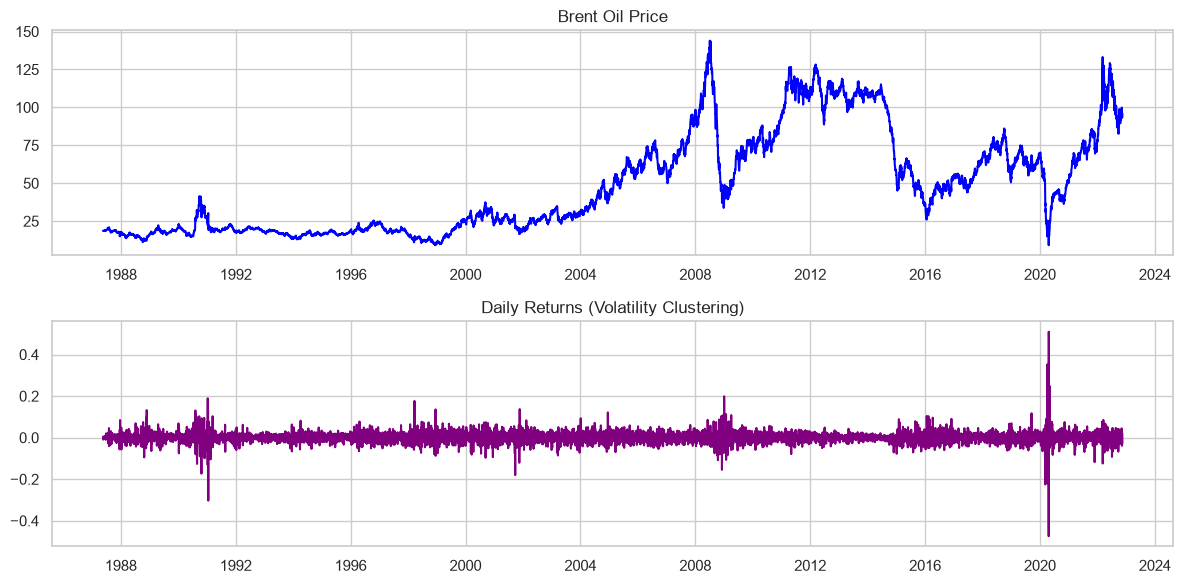

In [7]:
plt.subplot(2, 1, 1)
plt.plot(df['Price'], color='blue')
plt.title('Brent Oil Price')

plt.subplot(2, 1, 2)
plt.plot(df['Returns'], color='purple')
plt.title('Daily Returns (Volatility Clustering)')

plt.tight_layout()
plt.show()

# Create the Event Dataset 

In [8]:
import pandas as pd

events = [
    {"Date": "1990-08-02", "Event": "Gulf War", "Description": "Iraq invades Kuwait; supply fears."},
    {"Date": "1997-07-01", "Event": "Asian Financial Crisis", "Description": "Drop in oil demand from Asian markets."},
    {"Date": "2001-09-11", "Event": "9/11 Attacks", "Description": "Global economic slowdown/aviation fuel drop."},
    {"Date": "2003-03-20", "Event": "Iraq Invasion", "Description": "US-led invasion causes market uncertainty."},
    {"Date": "2008-07-11", "Event": "2008 Financial Crisis", "Description": "Prices peak then crash due to global recession."},
    {"Date": "2011-02-15", "Event": "Arab Spring", "Description": "Libyan civil war disruptions."},
    {"Date": "2014-11-27", "Event": "OPEC No-Cut Policy", "Description": "OPEC maintains production despite shale boom."},
    {"Date": "2016-11-30", "Event": "OPEC+ Agreement", "Description": "Russia and OPEC agree to joint cuts."},
    {"Date": "2020-03-08", "Event": "Saudi-Russia Price War", "Description": "Disagreement on cuts causes massive crash."},
    {"Date": "2020-04-20", "Event": "COVID-19 Lockdowns", "Description": "Global demand collapse; prices hit record lows."},
    {"Date": "2022-02-24", "Event": "Russia-Ukraine War", "Description": "Sanctions on Russia lead to price spikes."},
]

events_df = pd.DataFrame(events)
events_df.to_csv('../data/raw/external_events.csv', index=False)
print("✅ Event dataset created at ../data/raw/external_events.csv")

✅ Event dataset created at ../data/raw/external_events.csv


# Task 1: Analysis Foundation & Data Understanding

## 1. Data Analysis Workflow
Our analysis follows a structured path to identify structural breaks in Brent Oil prices:
1.  **Data Pre-processing:** Load and clean 30+ years of Brent Oil price data (1987-2022).
2.  **Exploratory Data Analysis:** Visualize trends using Moving Averages (30-day and 365-day) to filter noise.
3.  **Statistical Testing:** Perform Augmented Dickey-Fuller (ADF) tests to confirm non-stationarity of prices.
4.  **Change Point Detection:** Utilize the PELT algorithm to detect structural breaks where mean or variance shifts significantly.
5.  **Event Correlation:** Map detected change points to a curated list of 11+ geopolitical and economic events.
6.  **Modeling:** Fit segmented ARIMA models to different historical "regimes."

## 2. Time Series Properties Identified
*   **Trend:** The data shows a strong stochastic trend, notably the commodity super-cycle (2000-2008) and the subsequent crash.
*   **Stationarity:** The raw price series is **non-stationary** ($p > 0.05$). However, the log-returns are **stationary**, making them suitable for modeling.
*   **Volatility Clustering:** High-volatility events (like the 2008 Crisis and 2020 COVID crash) are clearly visible as "clusters" of large price returns.

## 3. Assumptions and Limitations
*   **Assumption of Piecewise Stationarity:** We assume that between change points, the statistical properties of the market remain relatively stable.
*   **Correlation vs. Causation:** This analysis identifies *statistical correlations* in time. While a change point may coincide with the start of the Russia-Ukraine war, we cannot mathematically prove the war was the *sole* cause without controlling for other global economic variables.
*   **Model Sensitivity:** Change point detection is sensitive to the "penalty" parameter. Too low a penalty results in over-segmentation; too high a penalty misses subtle but important shifts.

## 4. Expected Outputs
*   A list of specific dates representing structural breaks in the oil market.
*   An understanding of how specific events (OPEC decisions vs. Wars) impact volatility differently.